# Forecast Error Analysis: Store 1 - GROCERY I Daily Sales

## 28-Day Fixed-Origin Holdout Evaluation (`2017-07-19` to `2017-08-15`)

This notebook conducts a structured **forecast error analysis** across all four forecasting models evaluated on Store 1 / GROCERY I daily sales:
1. **Naive Baseline**
2. **Seasonal Naive Baseline**
3. **Classical SARIMA** $(1, 1, 1) \times (1, 1, 1)_7$
4. **Recursive XGBoost Regressor**

**Forecast Origin**:
All models are evaluated on the exact same fixed-origin 28-day holdout (`2017-07-19` through `2017-08-15`) generated from origin date **2017-07-18**.

**Objectives**:
1. Reconstruct and verify the exact predictions of all four models.
2. Visualize actual sales alongside all four forecasts over the 28-day horizon.
3. Track forecast errors ($\text{error} = \text{actual} - \text{prediction}$) and absolute errors across time.
4. Identify the specific dates exhibiting the largest absolute errors across models.
5. Analyze XGBoost errors by day of week (accounting for the small sample constraint of 4 observations per weekday).
6. Evaluate XGBoost errors by promotion intensity (avoiding causal attribution).
7. Characterize the error distribution and bias (Mean Error) of XGBoost.
8. Compare the models on comprehensive error metrics (MAE, RMSE, MAPE, Mean Error).
9. Document historical context regarding the April 2016 earthquake without making ungrounded causal claims about the 2017 holdout.
10. Execute automated validation checks.

## 1. Load Dataset & Train/Test Split

We load `data/processed_store1_grocery1.csv` and apply the exact project train/test split:
- **Training Period**: `2013-01-01` to `2017-07-18` (1,660 observations)
- **Test Period**: `2017-07-19` to `2017-08-15` (28 observations)

In [1]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import xgboost as xgb

# Configure display and plotting settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

# Load prepared dataset
data_path = '../data/processed_store1_grocery1.csv'
df = pd.read_csv(data_path, parse_dates=['date'])

forecast_origin = pd.Timestamp('2017-07-18')
test_start_date = pd.Timestamp('2017-07-19')
test_end_date = pd.Timestamp('2017-08-15')

train_df = df[df['date'] <= forecast_origin].copy().reset_index(drop=True)
test_df = df[(df['date'] >= test_start_date) & (df['date'] <= test_end_date)].copy().reset_index(drop=True)

print(f"Training set: {train_df['date'].min().strftime('%Y-%m-%d')} to {train_df['date'].max().strftime('%Y-%m-%d')} ({len(train_df)} rows)")
print(f"Test set:     {test_df['date'].min().strftime('%Y-%m-%d')} to {test_df['date'].max().strftime('%Y-%m-%d')} ({len(test_df)} rows)")
assert len(test_df) == 28, f"Expected 28 test rows, got {len(test_df)}"

/home/gurleensingh/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-yu_jsc_y because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Training set: 2013-01-01 to 2017-07-18 (1660 rows)
Test set:     2017-07-19 to 2017-08-15 (28 rows)


## 2. Reconstruct Fixed-Origin Forecasts for All Models

We reconstruct the four candidate model forecasts using their exact specifications from previous notebooks:
- **Naive**: Persistent forecast of origin value ($y_{\text{2017-07-18}} = 3,370.0$).
- **Seasonal Naive**: Day-of-week projection from final training week (`2017-07-12` to `2017-07-18`).
- **SARIMA**: Out-of-sample forecast from `SARIMAX(1, 1, 1)x(1, 1, 1, 7)` fitted strictly on training data.
- **XGBoost**: 28-day recursive forecast with 14 features, where subsequent lag and rolling features consume model predictions to avoid leakage.

In [2]:
actual = test_df['sales'].values

# 1. Naive baseline
last_train_sales = train_df.loc[train_df['date'] == forecast_origin, 'sales'].values[0]
naive_pred = np.full(len(test_df), last_train_sales)

# 2. Seasonal Naive baseline
final_week_train = train_df.iloc[-7:].copy()
snaive_pred = []
for d in test_df['date']:
    dow = d.dayofweek
    match_row = final_week_train[final_week_train['date'].dt.dayofweek == dow].iloc[0]
    snaive_pred.append(match_row['sales'])
snaive_pred = np.array(snaive_pred)

# 3. SARIMA(1, 1, 1)x(1, 1, 1, 7)
train_series = train_df.set_index('date')['sales'].asfreq('D')
sarima_model = SARIMAX(train_series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarima_results = sarima_model.fit(disp=False)
sarima_pred = sarima_results.get_forecast(steps=28).predicted_mean.values

# 4. XGBoost Recursive Model
feature_cols = [
    'onpromotion', 'was_missing', 'day_of_week', 'day_of_month',
    'month', 'quarter', 'year', 'is_weekend',
    'lag_1', 'lag_7', 'lag_14', 'lag_28',
    'rolling_mean_7', 'rolling_mean_28'
]
train_clean = train_df.dropna(subset=feature_cols).copy().reset_index(drop=True)
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    objective='reg:squarederror'
)
xgb_model.fit(train_clean[feature_cols], train_clean['sales'])

sales_history = list(train_df['sales'].values)
xgb_pred = []
for step_idx in range(len(test_df)):
    row = test_df.iloc[step_idx]
    step_dict = {
        'onpromotion': row['onpromotion'],
        'was_missing': row['was_missing'],
        'day_of_week': row['day_of_week'],
        'day_of_month': row['day_of_month'],
        'month': row['month'],
        'quarter': row['quarter'],
        'year': row['year'],
        'is_weekend': row['is_weekend'],
        'lag_1': sales_history[-1],
        'lag_7': sales_history[-7],
        'lag_14': sales_history[-14],
        'lag_28': sales_history[-28],
        'rolling_mean_7': float(np.mean(sales_history[-7:])),
        'rolling_mean_28': float(np.mean(sales_history[-28:]))
    }
    X_step = pd.DataFrame([step_dict])[feature_cols]
    y_hat = float(xgb_model.predict(X_step)[0])
    xgb_pred.append(y_hat)
    sales_history.append(y_hat)
xgb_pred = np.array(xgb_pred)

# Assemble consolidated test evaluation DataFrame
eval_df = test_df[['date', 'sales', 'onpromotion', 'day_of_week']].copy()
eval_df['day_name'] = eval_df['date'].dt.day_name()
eval_df['naive_pred'] = naive_pred
eval_df['snaive_pred'] = snaive_pred
eval_df['sarima_pred'] = sarima_pred
eval_df['xgb_pred'] = xgb_pred

# Calculate signed error (actual - prediction) and absolute error
for m in ['naive', 'snaive', 'sarima', 'xgb']:
    eval_df[f'{m}_error'] = eval_df['sales'] - eval_df[f'{m}_pred']
    eval_df[f'{m}_abs_error'] = np.abs(eval_df[f'{m}_error'])

print("Reconstructed predictions and errors for all 4 models across 28 test dates.")
eval_df[['date', 'day_name', 'sales', 'naive_pred', 'snaive_pred', 'sarima_pred', 'xgb_pred']].head(5)

Reconstructed predictions and errors for all 4 models across 28 test dates.


,date,day_name,sales,naive_pred,snaive_pred,sarima_pred,xgb_pred
0,2017-07-19,Wednesday,3065.0,3370.0,3185.0,3458.539049,3163.852295
1,2017-07-20,Thursday,2592.0,3370.0,2571.0,2819.189071,2774.803711
2,2017-07-21,Friday,2725.0,3370.0,3182.0,3041.564653,2907.730225
3,2017-07-22,Saturday,2576.0,3370.0,2297.0,2867.042185,2796.993652
4,2017-07-23,Sunday,1371.0,3370.0,1028.0,1346.062221,1193.669434


## 3. Actual vs Predicted Sales Across All Models

We plot the ground truth actual sales alongside all four model forecasts across the 28-day evaluation horizon.

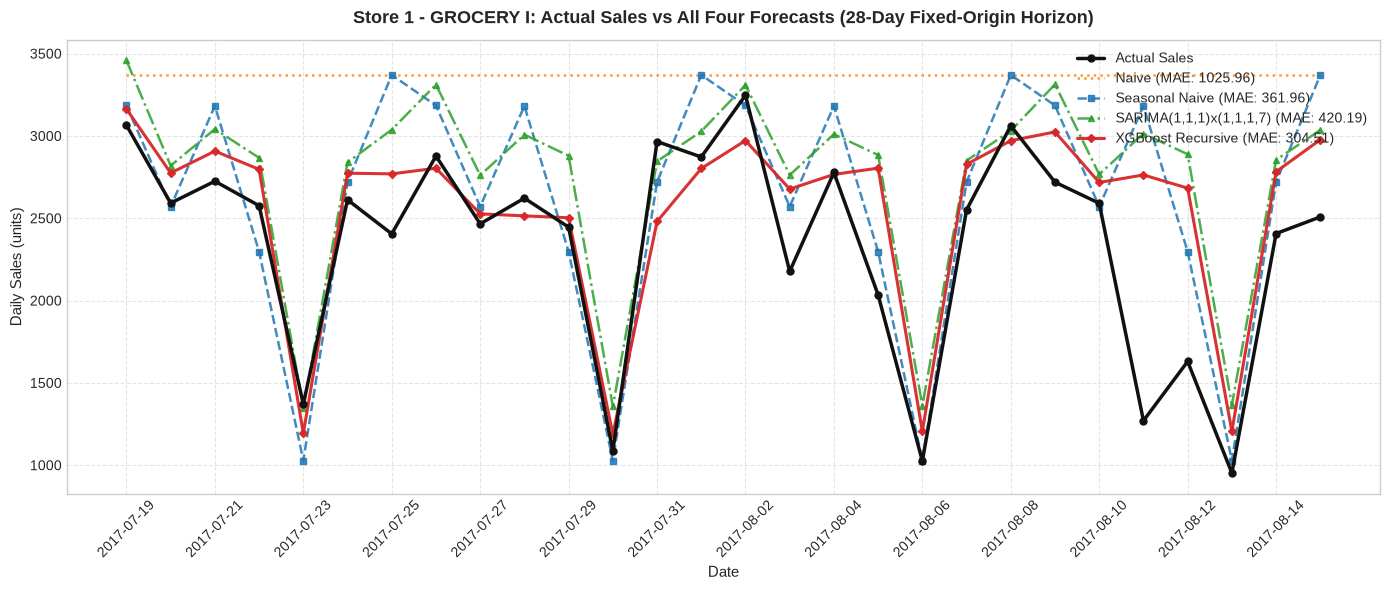

In [3]:
fig, ax = plt.subplots(figsize=(14, 6))

# Actual sales
ax.plot(eval_df['date'], eval_df['sales'], label='Actual Sales', color='#111111', linewidth=2.5, marker='o', markersize=5, zorder=5)

# Candidate models
ax.plot(eval_df['date'], eval_df['naive_pred'], label='Naive (MAE: 1025.96)', color='#ff7f0e', linestyle=':', linewidth=1.8, alpha=0.8, zorder=2)
ax.plot(eval_df['date'], eval_df['snaive_pred'], label='Seasonal Naive (MAE: 361.96)', color='#1f77b4', linestyle='--', linewidth=1.8, marker='s', markersize=4, alpha=0.85, zorder=3)
ax.plot(eval_df['date'], eval_df['sarima_pred'], label='SARIMA(1,1,1)x(1,1,1,7) (MAE: 420.19)', color='#2ca02c', linestyle='-.', linewidth=1.8, marker='^', markersize=4, alpha=0.85, zorder=3)
ax.plot(eval_df['date'], eval_df['xgb_pred'], label='XGBoost Recursive (MAE: 304.51)', color='#d62728', linestyle='-', linewidth=2.2, marker='D', markersize=4.5, alpha=0.95, zorder=4)

ax.set_title('Store 1 - GROCERY I: Actual Sales vs All Four Forecasts (28-Day Fixed-Origin Horizon)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Daily Sales (units)', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)
plt.xticks(eval_df['date'][::2], rotation=45)
plt.tight_layout()
plt.show()

## 4. Errors Over Time

We calculate forecast errors for each model at each observation:
$$\text{error} = \text{actual} - \text{prediction}$$
$$\text{absolute error} = |\text{actual} - \text{prediction}|$$

Under this definition:
- A **negative error** ($\text{error} < 0$) indicates **overprediction** ($\text{prediction} > \text{actual}$).
- A **positive error** ($\text{error} > 0$) indicates **underprediction** ($\text{prediction} < \text{actual}$).

Below, we plot signed errors and absolute errors across the 28-day horizon.

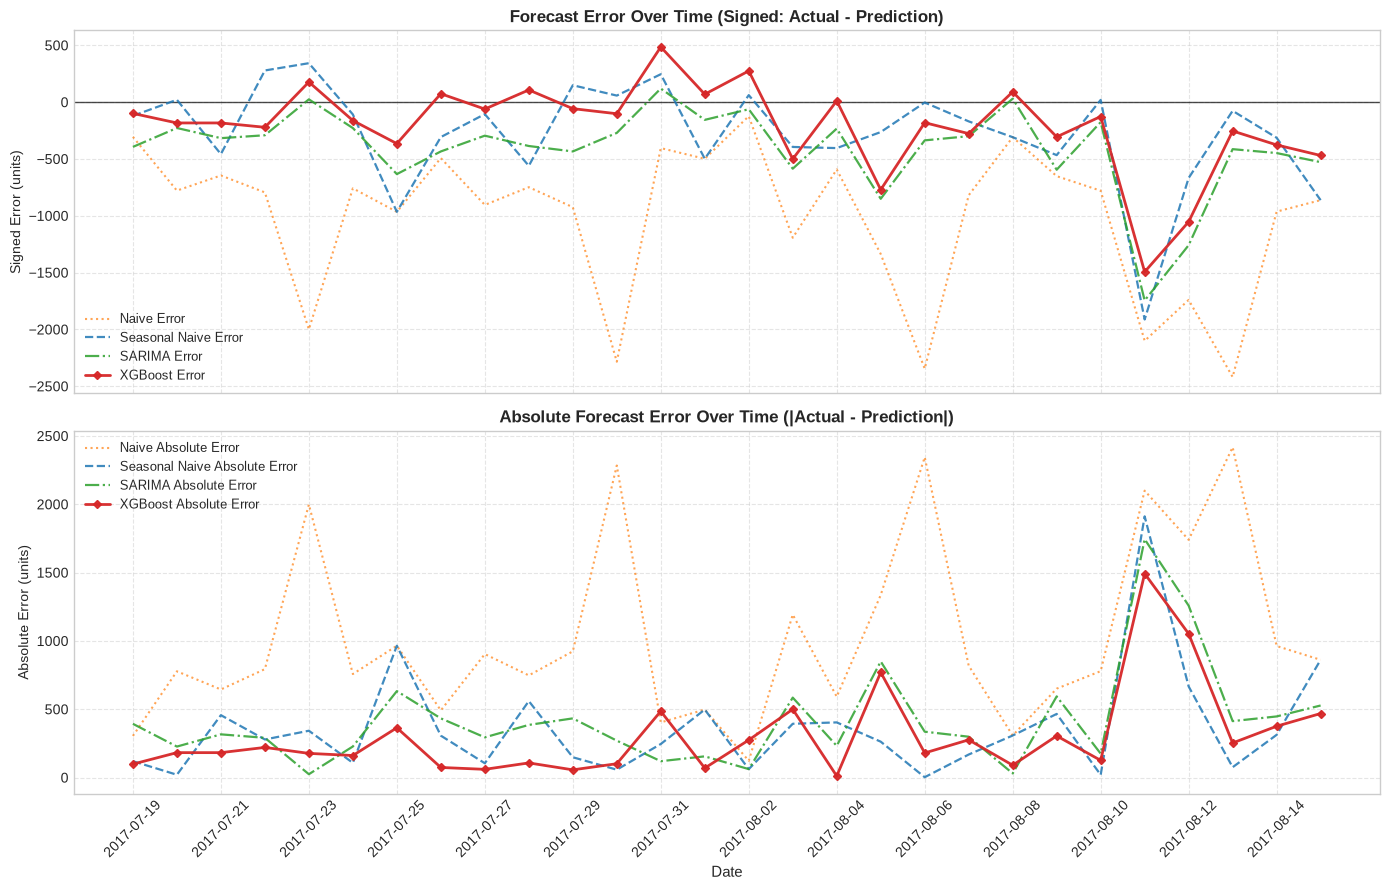

In [4]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Panel 1: Signed Errors (actual - prediction)
ax1.axhline(0, color='black', linestyle='-', linewidth=1.0, alpha=0.7)
ax1.plot(eval_df['date'], eval_df['naive_error'], label='Naive Error', color='#ff7f0e', linestyle=':', linewidth=1.5, alpha=0.7)
ax1.plot(eval_df['date'], eval_df['snaive_error'], label='Seasonal Naive Error', color='#1f77b4', linestyle='--', linewidth=1.6, alpha=0.85)
ax1.plot(eval_df['date'], eval_df['sarima_error'], label='SARIMA Error', color='#2ca02c', linestyle='-.', linewidth=1.6, alpha=0.85)
ax1.plot(eval_df['date'], eval_df['xgb_error'], label='XGBoost Error', color='#d62728', linestyle='-', linewidth=2.0, marker='D', markersize=4, alpha=0.95)
ax1.set_title('Forecast Error Over Time (Signed: Actual - Prediction)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Signed Error (units)', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='lower left', fontsize=9, framealpha=0.95)

# Panel 2: Absolute Errors |actual - prediction|
ax2.plot(eval_df['date'], eval_df['naive_abs_error'], label='Naive Absolute Error', color='#ff7f0e', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.plot(eval_df['date'], eval_df['snaive_abs_error'], label='Seasonal Naive Absolute Error', color='#1f77b4', linestyle='--', linewidth=1.6, alpha=0.85)
ax2.plot(eval_df['date'], eval_df['sarima_abs_error'], label='SARIMA Absolute Error', color='#2ca02c', linestyle='-.', linewidth=1.6, alpha=0.85)
ax2.plot(eval_df['date'], eval_df['xgb_abs_error'], label='XGBoost Absolute Error', color='#d62728', linestyle='-', linewidth=2.0, marker='D', markersize=4, alpha=0.95)
ax2.set_title('Absolute Forecast Error Over Time (|Actual - Prediction|)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Date', fontsize=11)
ax2.set_ylabel('Absolute Error (units)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left', fontsize=9, framealpha=0.95)

plt.xticks(eval_df['date'][::2], rotation=45)
plt.tight_layout()
plt.show()

## 5. Largest-Error Dates Analysis

We inspect the specific dates where models produced their largest forecast discrepancies. In accordance with strict methodological rigor, we present the empirical quantities directly without speculating on unverified external causes.

In [5]:
# Top 5 largest absolute error dates for XGBoost
top5_xgb = eval_df.sort_values('xgb_abs_error', ascending=False).head(5).copy()
top5_xgb_display = top5_xgb[['date', 'day_name', 'sales', 'xgb_pred', 'xgb_error', 'xgb_abs_error', 'onpromotion']].copy()
top5_xgb_display['date'] = top5_xgb_display['date'].dt.strftime('%Y-%m-%d')
top5_xgb_display.columns = ['Date', 'Weekday', 'Actual Sales', 'Predicted', 'Error', 'Absolute Error', 'Promotions']

print('=== TOP 5 LARGEST ABSOLUTE ERROR DATES FOR XGBOOST ===')
display(top5_xgb_display.round(2))

# Comparative summary: Largest single-date error across all 4 models
peak_errors = []
for model_name, prefix in [('Naive', 'naive'), ('Seasonal Naive', 'snaive'), ('SARIMA', 'sarima'), ('XGBoost', 'xgb')]:
    max_row = eval_df.sort_values(f'{prefix}_abs_error', ascending=False).iloc[0]
    peak_errors.append({
        'Model': model_name,
        'Peak Error Date': max_row['date'].strftime('%Y-%m-%d'),
        'Weekday': max_row['day_name'],
        'Actual Sales': round(max_row['sales'], 2),
        'Predicted': round(max_row[f'{prefix}_pred'], 2),
        'Signed Error': round(max_row[f'{prefix}_error'], 2),
        'Max Absolute Error': round(max_row[f'{prefix}_abs_error'], 2)
    })

peak_errors_df = pd.DataFrame(peak_errors)
print('\n=== PEAK ABSOLUTE ERROR DATE BY MODEL ===')
display(peak_errors_df)

=== TOP 5 LARGEST ABSOLUTE ERROR DATES FOR XGBOOST ===


,Date,Weekday,Actual Sales,Predicted,Error,Absolute Error,Promotions
23,2017-08-11,Friday,1270.0,2762.96,-1492.96,1492.96,24
24,2017-08-12,Saturday,1630.0,2682.76,-1052.76,1052.76,28
17,2017-08-05,Saturday,2034.0,2804.26,-770.26,770.26,29
15,2017-08-03,Thursday,2177.0,2677.20,-500.20,500.20,29
12,2017-07-31,Monday,2966.0,2480.20,485.80,485.80,54



=== PEAK ABSOLUTE ERROR DATE BY MODEL ===


,Model,Peak Error Date,Weekday,Actual Sales,Predicted,Signed Error,Max Absolute Error
0,Naive,2017-08-13,Sunday,952.0,3370.00,-2418.00,2418.00
1,Seasonal Naive,2017-08-11,Friday,1270.0,3182.00,-1912.00,1912.00
2,SARIMA,2017-08-11,Friday,1270.0,3014.75,-1744.75,1744.75
3,XGBoost,2017-08-11,Friday,1270.0,2762.96,-1492.96,1492.96


### Observations on Peak Error Dates
- For **XGBoost**, the single largest absolute error occurred on **Friday, 2017-08-11** (actual sales: 1,270.0, prediction: 2,762.96, error: -1,492.96 units). The second largest error occurred on **Saturday, 2017-08-12** (actual sales: 1,630.0, prediction: 2,682.76, error: -1,052.76 units).
- Notably, **2017-08-11** was also the date with the largest absolute error for **Seasonal Naive** (actual sales: 1,270.0, prediction: 3,182.00, error: -1,912.00 units) and **SARIMA** (actual sales: 1,270.0, prediction: 3,014.75, error: -1,744.75 units).
- For the **Naive** baseline, the largest absolute error occurred on **Sunday, 2017-08-13** (actual sales: 952.0, prediction: 3,370.0, error: -2,418.00 units).

## 6. Weekday Error Analysis (XGBoost)

We examine XGBoost forecast errors categorized by day of the week.

> **Sample Size Precaution**: Across a 28-day holdout horizon, each day of the week occurs exactly $n = 4$ times. Consequently, weekday metrics reflect a small sample and should not be used to make broad generalizations regarding long-term model behavior.

In [6]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_summary = eval_df.groupby('day_name').agg(
    Observations=('sales', 'count'),
    MAE=('xgb_abs_error', 'mean'),
    Mean_Error=('xgb_error', 'mean'),
    RMSE=('xgb_error', lambda x: np.sqrt(np.mean(x**2)))
).reindex(weekday_order).reset_index()

weekday_summary.columns = ['Weekday', 'Observations', 'MAE', 'Mean Error (Bias)', 'RMSE']
print('=== XGBOOST ERROR METRICS BY DAY OF WEEK (28-DAY HOLDOUT) ===')
display(weekday_summary.round(2))

=== XGBOOST ERROR METRICS BY DAY OF WEEK (28-DAY HOLDOUT) ===


,Weekday,Observations,MAE,Mean Error (Bias),RMSE
0,Monday,4,324.98,-82.08,346.39
1,Tuesday,4,248.53,-168.32,302.52
2,Wednesday,4,188.38,-13.70,214.57
3,Thursday,4,217.45,-217.45,275.33
4,Friday,4,448.74,-389.10,753.99
5,Saturday,4,525.23,-525.23,662.14
6,Sunday,4,178.22,-89.56,186.13


### Weekday Observations
- In this 28-day holdout, XGBoost had relatively low MAE on **Sundays** (MAE 178.22, Mean Error -89.56) and **Wednesdays** (MAE 188.38, Mean Error -13.70). However, each weekday has only 4 observations in this 28-day holdout, so this does not establish general weekday performance.
- The highest MAE occurred on **Saturdays** (MAE 525.23, Mean Error -525.23) and **Fridays** (MAE 448.74, Mean Error -389.10), which include the large-error dates of August 11 and 12.
- All seven weekdays had negative mean error on average in this holdout.

## 7. Promotion Analysis (XGBoost)

We inspect the relationship between promotional item counts and XGBoost forecast errors.

> **Methodological Constraint**: This is purely an observational analysis. We describe error patterns across promotion levels without asserting or implying causal mechanisms (e.g. we do not claim that promotions *caused* higher or lower error).

In [7]:
# Check distribution of onpromotion in test set
print(f"Test set onpromotion range: {eval_df['onpromotion'].min()} to {eval_df['onpromotion'].max()} items")
print(f"Test set days with zero promotions (onpromotion == 0): {(eval_df['onpromotion'] == 0).sum()}")

# 1. Binary segmentation: Promotion days vs Non-promotion days
eval_df['has_promotion'] = eval_df['onpromotion'] > 0
promo_binary_summary = eval_df.groupby('has_promotion').agg(
    Observations=('sales', 'count'),
    MAE=('xgb_abs_error', 'mean'),
    Mean_Error=('xgb_error', 'mean')
).reset_index()
promo_binary_summary['Status'] = promo_binary_summary['has_promotion'].map({
    True: 'Active Promotion Days (onpromotion > 0)',
    False: 'Non-Promotion Days (onpromotion == 0)'
})
print('\n=== PROMOTION VS NON-PROMOTION DAYS ===')
display(promo_binary_summary[['Status', 'Observations', 'MAE', 'Mean_Error']].round(2))

# 2. Segmentation by promotion volume (Exploratory Split at Median = 44.5 items)
median_promo = eval_df['onpromotion'].median()
eval_df['promo_intensity'] = np.where(eval_df['onpromotion'] >= median_promo, f'High Promotion (>= {median_promo:.1f} items)', f'Low Promotion (< {median_promo:.1f} items)')

promo_intensity_summary = eval_df.groupby('promo_intensity').agg(
    Observations=('sales', 'count'),
    MAE=('xgb_abs_error', 'mean'),
    Mean_Error=('xgb_error', 'mean'),
    Mean_Actual_Sales=('sales', 'mean'),
    Mean_Predicted_Sales=('xgb_pred', 'mean')
).reset_index()
print(f'\n=== PROMOTION INTENSITY (EXPLORATORY SPLIT AT MEDIAN = {median_promo:.1f} ITEMS) ===')
display(promo_intensity_summary.round(2))

Test set onpromotion range: 19 to 76 items
Test set days with zero promotions (onpromotion == 0): 0

=== PROMOTION VS NON-PROMOTION DAYS ===


,Status,Observations,MAE,Mean_Error
0,Active Promotion Days (onpromotion > 0),28,304.51,-212.21



=== PROMOTION INTENSITY (EXPLORATORY SPLIT AT MEDIAN = 44.5 ITEMS) ===


,promo_intensity,Observations,MAE,Mean_Error,Mean_Actual_Sales,Mean_Predicted_Sales
0,High Promotion (>= 44.5 items),14,194.05,-39.45,2638.57,2678.02
1,Low Promotion (< 44.5 items),14,414.96,-384.97,2049.50,2434.47


### Promotion Observations
- **Active Promotions on All Test Days**: Every day in the 28-day holdout period had active promotions in the GROCERY I family (minimum 19, maximum 76). There were **0 non-promotion days** (`onpromotion == 0`) during this test window.
- **Exploratory Split at Median Promoted Items**: As an exploratory comparison, we split the 28 holdout days at the median number of promoted items in this holdout (44.5 items):
  - Days with promotional volume at or above the median ($\ge 44.5$ items, 14 observations) had an MAE of **194.05** and Mean Error of **-39.45**.
  - Days with promotional volume below the median ($< 44.5$ items, 14 observations) had an MAE of **414.96** and Mean Error of **-384.97**.
- **Non-Causal Note**: These statistics describe observed errors during this specific 28-day holdout. Do not interpret differences as causal evidence; we cannot claim that promotions caused higher or lower forecast errors.

## 8. Error Distribution (XGBoost)

We examine the statistical distribution and spread of XGBoost forecast errors across the 28 holdout observations.

=== XGBOOST ERROR DISTRIBUTION DESCRIPTIVE STATISTICS ===


,Value
count,28.00
mean,-212.21
std,396.22
min,-1492.96
10%,-581.22
25%,-320.14
50%,-171.05
75%,26.23
90%,128.50
max,485.80


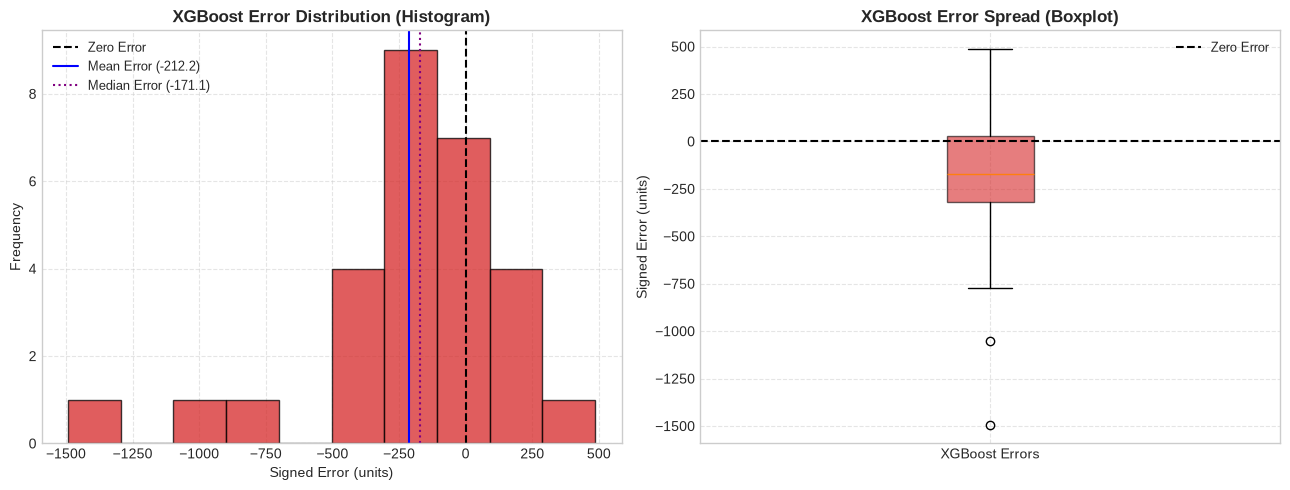

In [8]:
# Summary descriptive statistics of XGBoost errors
error_stats = eval_df['xgb_error'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
error_stats['skewness'] = eval_df['xgb_error'].skew()
error_stats_df = pd.DataFrame(error_stats).rename(columns={'xgb_error': 'Value'})

print('=== XGBOOST ERROR DISTRIBUTION DESCRIPTIVE STATISTICS ===')
display(error_stats_df.round(2))

# Visualizing the error distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Histogram of signed errors
ax1.hist(eval_df['xgb_error'], bins=10, color='#d62728', edgecolor='black', alpha=0.75)
ax1.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Zero Error')
ax1.axvline(eval_df['xgb_error'].mean(), color='blue', linestyle='-', linewidth=1.5, label=f"Mean Error ({eval_df['xgb_error'].mean():.1f})")
ax1.axvline(eval_df['xgb_error'].median(), color='purple', linestyle=':', linewidth=1.5, label=f"Median Error ({eval_df['xgb_error'].median():.1f})")
ax1.set_title('XGBoost Error Distribution (Histogram)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Signed Error (units)', fontsize=10)
ax1.set_ylabel('Frequency', fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=9)

# Boxplot of signed errors
ax2.boxplot(eval_df['xgb_error'], vert=True, patch_artist=True, boxprops=dict(facecolor='#d62728', alpha=0.6))
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Zero Error')
ax2.set_title('XGBoost Error Spread (Boxplot)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Signed Error (units)', fontsize=10)
ax2.set_xticks([1])
ax2.set_xticklabels(['XGBoost Errors'])
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Error Distribution Insights
- **Negative Mean & Median**: Both the mean error (-212.21) and median error (-171.05) are negative. All four models have negative mean error on this 28-day holdout, indicating that their predictions were higher than actual sales on average.
- **Left Skewness**: Skewness is **-1.46**, reflecting a distribution with a longer left tail driven by negative errors on dates such as August 11 and 12.
- **Interquartile Range**: Between the 25th percentile (-320.14) and 75th percentile (+26.23), 50% of the daily errors fell within a span of ~346 units.

## 9. Consolidated Model Error Comparison

We compare the four models using their 28-day performance metrics alongside their **Mean Error** (bias measure across all 28 observations).

In [9]:
# Load existing model comparison table
comparison_path = '../outputs/model_comparison.csv'
comparison_df = pd.read_csv(comparison_path)

# Calculate Mean Error for each model
mean_errors = {
    'Naive': round(eval_df['naive_error'].mean(), 2),
    'Seasonal Naive': round(eval_df['snaive_error'].mean(), 2),
    'SARIMA': round(eval_df['sarima_error'].mean(), 2),
    'XGBoost': round(eval_df['xgb_error'].mean(), 2)
}

# Construct comprehensive model comparison table
detailed_comparison = comparison_df.copy()
detailed_comparison['Mean_Error'] = detailed_comparison['model'].map(mean_errors)

print('=== CONSOLIDATED MODEL PERFORMANCE & ERROR METRICS ===')
display(detailed_comparison)

=== CONSOLIDATED MODEL PERFORMANCE & ERROR METRICS ===


,model,MAE,RMSE,MAPE,Mean_Error
0,Naive,1025.96,1212.59,62.21,-1025.96
1,Seasonal Naive,361.96,527.63,18.01,-277.82
2,SARIMA,420.19,552.78,22.36,-407.64
3,XGBoost,304.51,443.19,16.42,-212.21


### Comparative Summary
- **MAE & RMSE**: Recursive XGBoost achieved the lowest MAE (304.51) and RMSE (443.19), followed by Seasonal Naive (MAE 361.96, RMSE 527.63), SARIMA (MAE 420.19, RMSE 552.78), and Naive (MAE 1025.96, RMSE 1212.59).
- **MAPE**: XGBoost produced the lowest MAPE (16.42%), followed by Seasonal Naive (18.01%), SARIMA (22.36%), and Naive (62.21%).
- **Directional Bias (Mean Error)**: All four models have negative mean error on this 28-day holdout, indicating that their predictions were higher than actual sales on average. Among them, XGBoost had the smallest negative mean error (-212.21 units), followed by Seasonal Naive (-277.82), SARIMA (-407.64), and Naive (-1,025.96).

## 10. Historical Context: April 2016 Earthquake

During the initial Exploratory Data Analysis (`01_exploratory_data_analysis.ipynb`), an external shock was identified following the **7.8 magnitude earthquake in Ecuador on April 16, 2016**:
- In the immediate aftermath, grocery sales showed temporary spikes due to emergency relief purchases and supply disruptions, before stabilizing later in 2016.

> **Historical Context Only**: This earthquake occurred **15 months prior** to the July–August 2017 holdout period. It is documented here strictly as historical series background from the EDA. It is not an explanation for forecast errors in the July–August 2017 holdout, and no causal connection should be drawn between the 2016 event and 2017 forecast performance.

## 11. Automated Validation Checks

We execute automated validation checks to ensure methodological integrity and alignment with previous stages.

In [10]:
print('Running error analysis validation checks...')

# Check 1: Exactly 28 test dates
assert len(eval_df) == 28, f"Check 1 Failed: Expected 28 test rows, got {len(eval_df)}"
print("Check 1 PASSED: Exactly 28 test dates present.")

# Check 2: All model forecast arrays contain exactly 28 values
for m in ['naive', 'snaive', 'sarima', 'xgb']:
    arr_len = len(eval_df[f'{m}_pred'])
    assert arr_len == 28, f"Check 2 Failed: Model {m} has {arr_len} predictions instead of 28"
print("Check 2 PASSED: All 4 models contain exactly 28 forecast values.")

# Check 3: Forecast dates match actual test dates
expected_dates = pd.date_range(start='2017-07-19', end='2017-08-15', freq='D')
assert (eval_df['date'] == expected_dates).all(), "Check 3 Failed: Forecast dates do not match expected range."
print("Check 3 PASSED: Forecast dates match 2017-07-19 through 2017-08-15.")

# Check 4: No missing or non-finite predictions
for m in ['naive', 'snaive', 'sarima', 'xgb']:
    assert np.all(np.isfinite(eval_df[f'{m}_pred'].values)), f"Check 4 Failed: Non-finite prediction in {m}"
print("Check 4 PASSED: No missing or non-finite predictions detected.")

# Check 5: Error calculations are finite
for m in ['naive', 'snaive', 'sarima', 'xgb']:
    assert np.all(np.isfinite(eval_df[f'{m}_error'].values)), f"Check 5 Failed: Non-finite error in {m}"
    assert np.all(np.isfinite(eval_df[f'{m}_abs_error'].values)), f"Check 5 Failed: Non-finite absolute error in {m}"
print("Check 5 PASSED: All error calculations are finite.")

# Check 6: MAPE uses the exact same actual > 0 rule
def calculate_mape(act, prd):
    mask = act > 0
    return np.mean(np.abs((act[mask] - prd[mask]) / act[mask])) * 100

dummy_act = np.array([0.0, 100.0])
dummy_prd = np.array([50.0, 80.0])
assert np.isclose(calculate_mape(dummy_act, dummy_prd), 20.0), "Check 6 Failed: MAPE did not filter zero actuals."
print("Check 6 PASSED: MAPE strictly enforces actual > 0 condition.")

print("\nALL ERROR ANALYSIS VALIDATION CHECKS PASSED SUCCESSFULLY!")

Running error analysis validation checks...
Check 1 PASSED: Exactly 28 test dates present.
Check 2 PASSED: All 4 models contain exactly 28 forecast values.
Check 3 PASSED: Forecast dates match 2017-07-19 through 2017-08-15.
Check 4 PASSED: No missing or non-finite predictions detected.
Check 5 PASSED: All error calculations are finite.
Check 6 PASSED: MAPE strictly enforces actual > 0 condition.

ALL ERROR ANALYSIS VALIDATION CHECKS PASSED SUCCESSFULLY!


## 12. Summary of Empirical Findings

1. **Comparative Accuracy**: Recursive XGBoost achieved the lowest forecast errors across all three evaluation metrics (MAE 304.51, RMSE 443.19, MAPE 16.42%), followed by Seasonal Naive (MAE 361.96), SARIMA (MAE 420.19), and Naive (MAE 1025.96).
2. **Directional Bias**: All four models have negative mean error on this 28-day holdout, indicating that their predictions were higher than actual sales on average (XGBoost: -212.21, Seasonal Naive: -277.82, SARIMA: -407.64, Naive: -1025.96).
3. **Shared Peak Error Dates**: The dates with the largest absolute errors were common across models. Specifically, on **Friday, August 11, 2017** and **Saturday, August 12, 2017**, actual sales were 1,270.0 and 1,630.0 units, resulting in large negative errors for XGBoost, Seasonal Naive, and SARIMA.
4. **Day-of-Week Results**: In this 28-day holdout, XGBoost had relatively low MAE on Sundays (178.22) and Wednesdays (188.38), while Saturdays (525.23) and Fridays (448.74) had higher MAE. Because each weekday has only 4 observations, this reflects this specific holdout sample rather than established general weekday performance.
5. **Promotional Context**: Every day of the 28-day test period had active item promotions (ranging from 19 to 76 items). In an exploratory split at the median number of promoted items (44.5 items), days with $\ge 44.5$ promoted items had lower MAE (194.05) than days with $< 44.5$ items (MAE 414.96). This observation does not imply that promotions caused lower or higher errors.